In [14]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.5/107.7 GB disk)


In [15]:
import gc
import torch
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from io import BytesIO
import numpy as np
import time
from ultralytics import YOLO


In [16]:
# a) Tải mô hình Faster R-CNN pre-trained trên COCO
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# Danh sách nhãn của COCO
COCO_CLASSES = weights.meta["categories"]


In [17]:
# Khởi tạo mô hình YOLOv8 nano pre-trained
yolo_model = YOLO('yolov8n.pt')

# Hiển thị thông tin các lớp (classes) mà mô hình hỗ trợ
print(f"Mô hình YOLOv8 đã tải thành công.")
print(f"Số lượng lớp hỗ trợ: {len(yolo_model.names)}")
print("Danh sách 10 lớp đầu tiên:", {k: yolo_model.names[k] for k in range(10)})

Mô hình YOLOv8 đã tải thành công.
Số lượng lớp hỗ trợ: 80
Danh sách 10 lớp đầu tiên: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}


In [18]:
def benchmark_models(model_frcnn, model_yolo, urls, iterations=10):
    results = {'Faster R-CNN': [], 'YOLOv8': []}
    transform = T.Compose([T.ToTensor()])

    # Tải ảnh trước để không tính thời gian tải mạng vào benchmark
    images = []
    for url in urls:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        images.append(img)

    # Benchmark Faster R-CNN
    print("Benchmarking Faster R-CNN...")
    for img in images:
        img_tensor = transform(img).unsqueeze(0) # Batch size 1
        durations = []
        for _ in range(iterations):
            start_time = time.perf_counter()
            with torch.no_grad():
                _ = model_frcnn(img_tensor)
            durations.append(time.perf_counter() - start_time)
        results['Faster R-CNN'].append(np.mean(durations))

    # Benchmark YOLOv8
    print("Benchmarking YOLOv8...")
    for img in images:
        durations = []
        for _ in range(iterations):
            start_time = time.perf_counter()
            _ = model_yolo.predict(img, verbose=False)
            durations.append(time.perf_counter() - start_time)
        results['YOLOv8'].append(np.mean(durations))

    # Tính toán kết quả tổng hợp
    for model_name, times in results.items():
        avg_time = np.mean(times)
        fps = 1 / avg_time
        print(f"\n{model_name}:")
        print(f"  - Average Inference Time: {avg_time:.4f}s")
        print(f"  - Average FPS: {fps:.2f}")

    return results



In [19]:
# Chạy benchmark
url_1 = "http://images.cocodataset.org/val2017/000000039769.jpg" # Ảnh hai con mèo
url_2 = "http://images.cocodataset.org/val2017/000000000139.jpg" # Ảnh phòng khách
url_3 = "http://images.cocodataset.org/val2017/000000000632.jpg" # Ảnh đường phố

image_urls = [url_1, url_2, url_3]
performance_data = benchmark_models(model, yolo_model, image_urls)

Benchmarking Faster R-CNN...
Benchmarking YOLOv8...

Faster R-CNN:
  - Average Inference Time: 9.6533s
  - Average FPS: 0.10

YOLOv8:
  - Average Inference Time: 0.2151s
  - Average FPS: 4.65


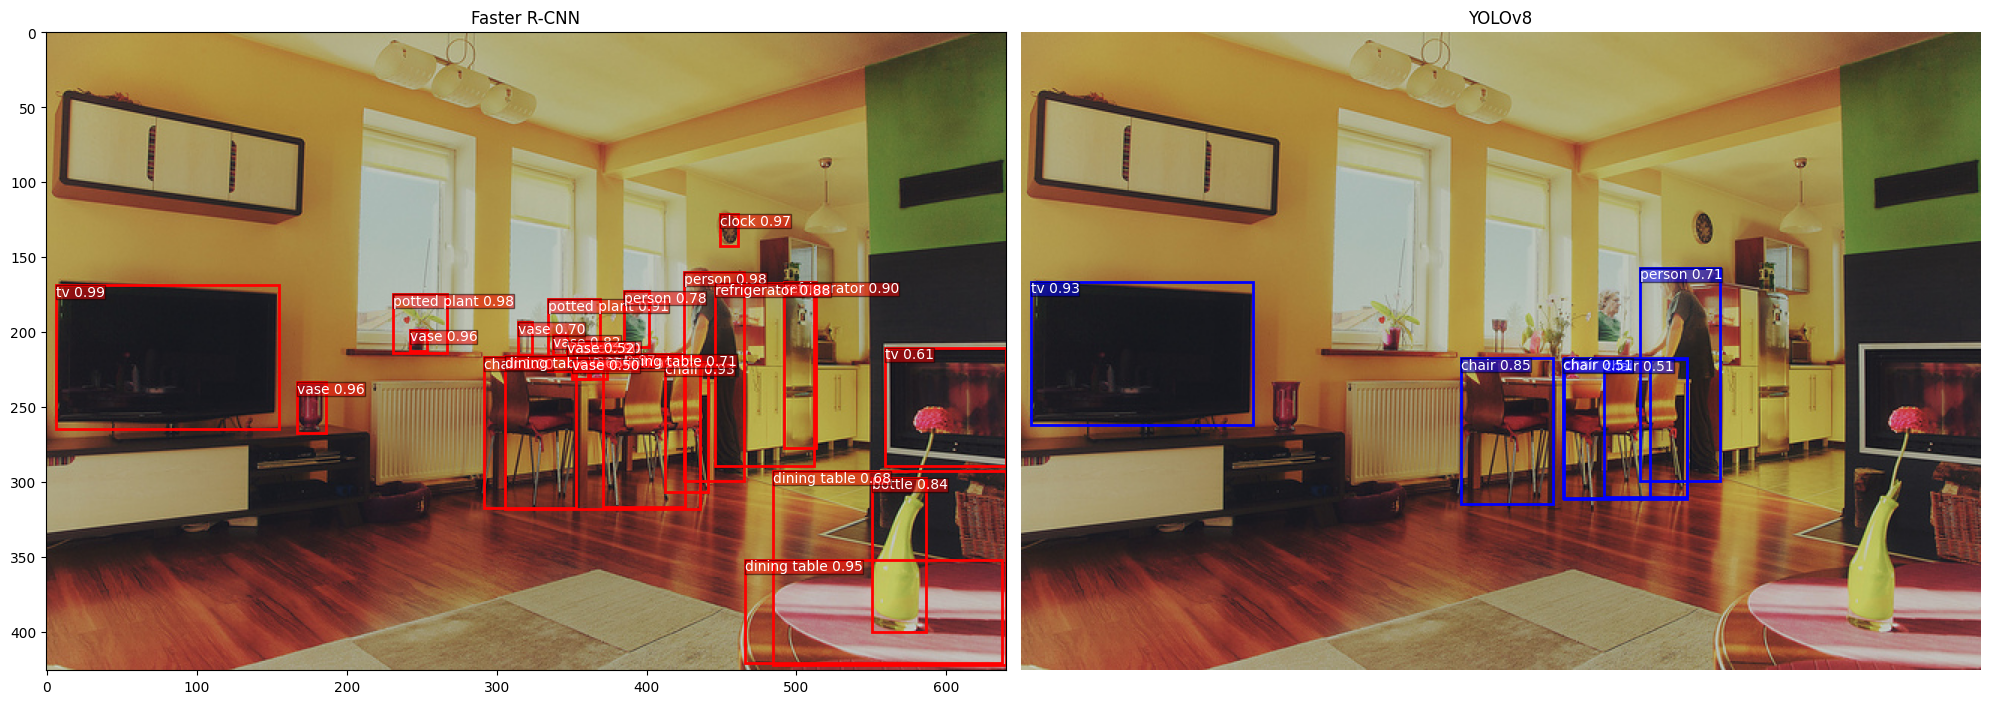

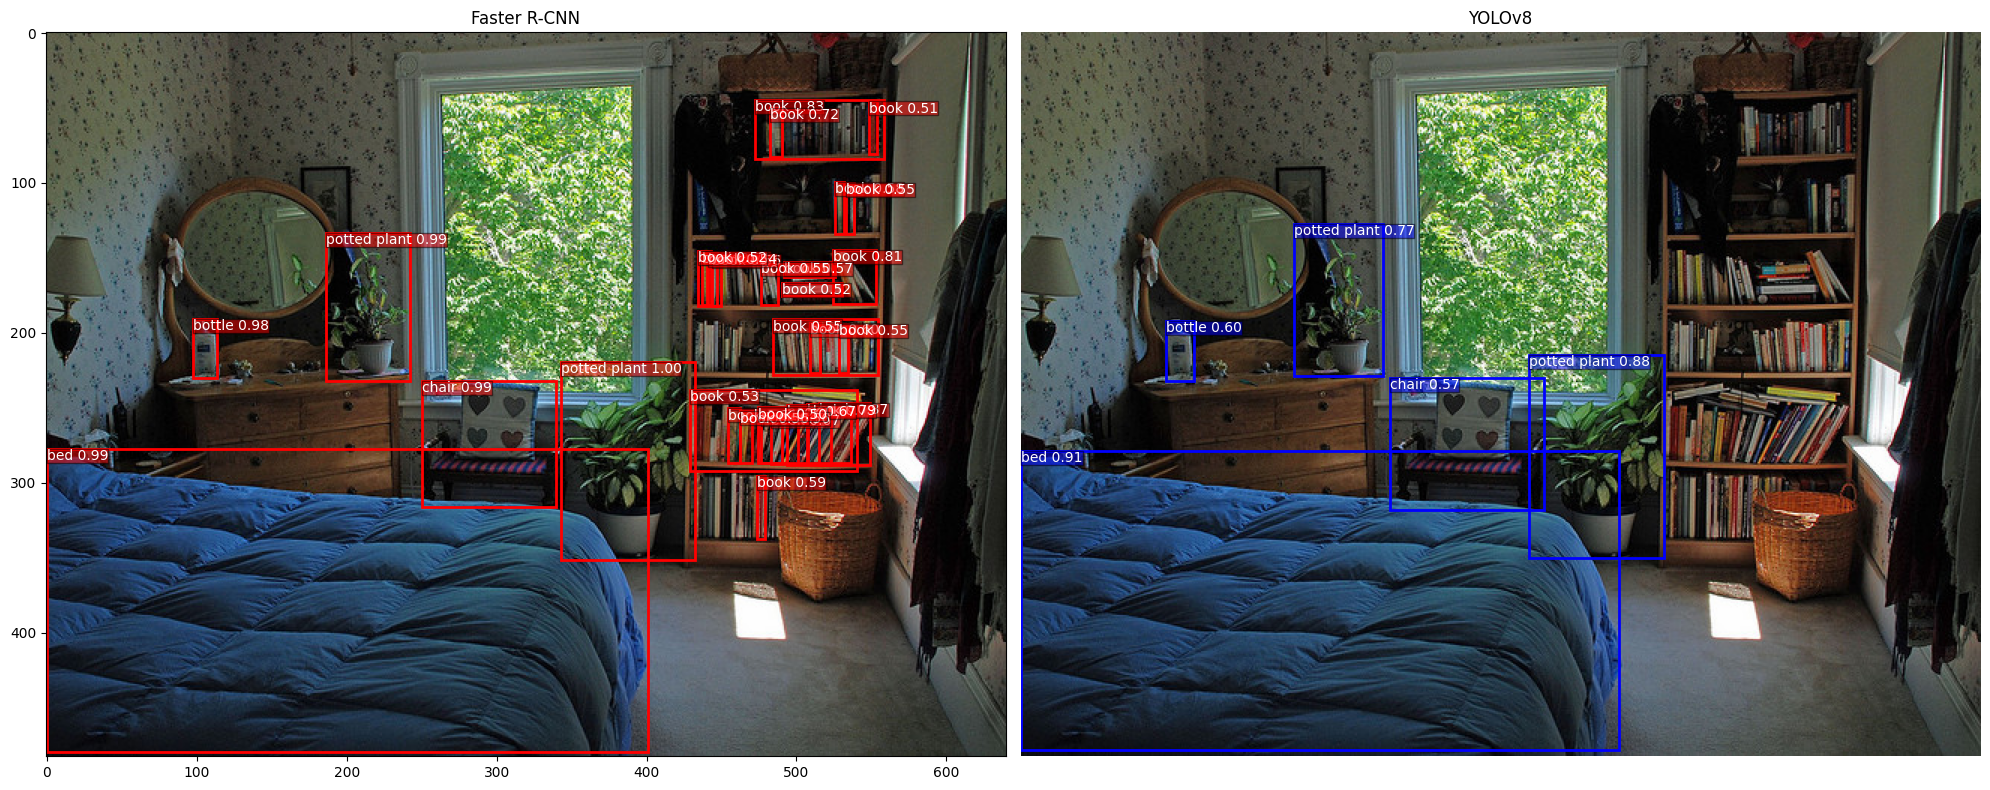

In [27]:
def compare_detections(url, threshold=0.5):
    # 1. Tải và chuẩn bị ảnh
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    # Chuẩn bị cho Faster R-CNN
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(img)

    # 2. Dự đoán với Faster R-CNN
    with torch.no_grad():
        frcnn_pred = model([img_tensor])[0]

    # 3. Dự đoán với YOLOv8
    yolo_results = yolo_model.predict(img, conf=threshold, verbose=False)[0]

    # 4. Vẽ kết quả
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Vẽ Faster R-CNN
    ax1.imshow(img)
    ax1.set_title("Faster R-CNN")
    for i in range(len(frcnn_pred['scores'])):
        score = frcnn_pred['scores'][i].item()
        if score > threshold:
            box = frcnn_pred['boxes'][i].detach().cpu().numpy()
            label = COCO_CLASSES[frcnn_pred['labels'][i].item()]
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='red', facecolor='none')
            ax1.add_patch(rect)
            ax1.text(box[0], box[1], f'{label} {score:.2f}', color='white', verticalalignment='top', bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})

    # Vẽ YOLOv8
    ax2.imshow(img)
    ax2.set_title("YOLOv8")
    for box in yolo_results.boxes:
        b = box.xyxy[0].cpu().numpy() #
        cls = int(box.cls[0])
        conf = box.conf[0]
        label = yolo_model.names[cls]
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=2, edgecolor='blue', facecolor='none')
        ax2.add_patch(rect)
        ax2.text(b[0], b[1], f'{label} {conf:.2f}', color='white', verticalalignment='top', bbox={'facecolor': 'blue', 'alpha': 0.5, 'pad': 0})

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Thực hiện so sánh trên các ảnh mẫu
compare_detections(url_2)
compare_detections(url_3)

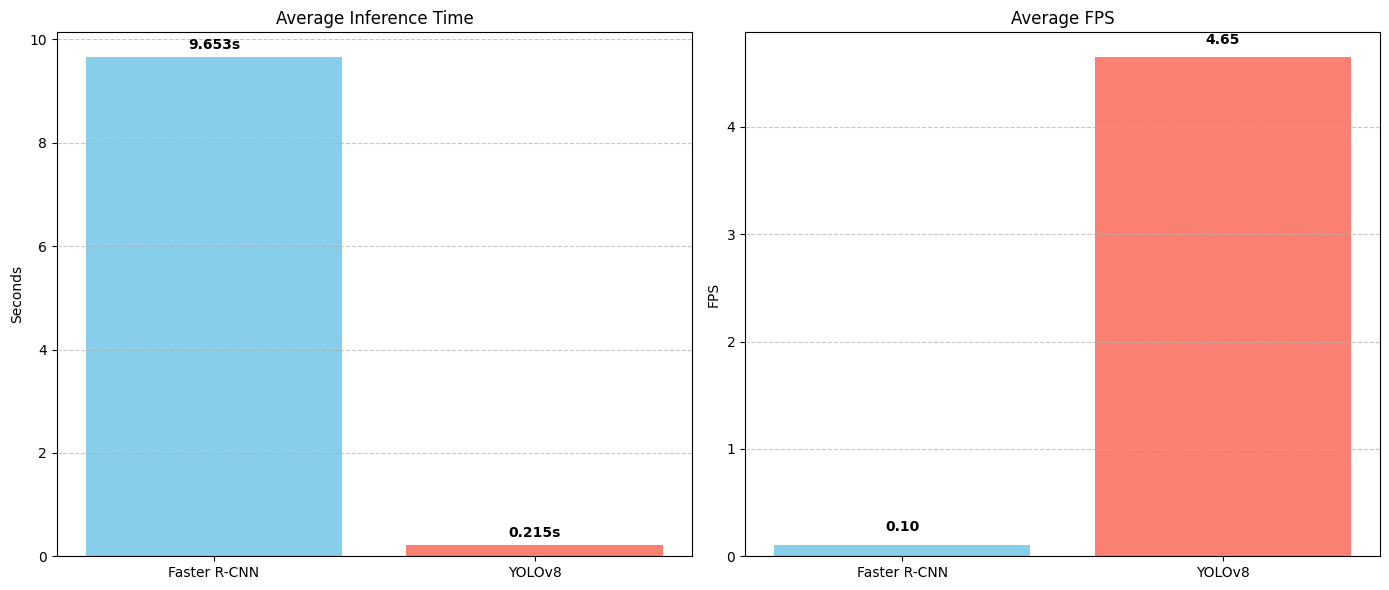

In [28]:
models = list(performance_data.keys())
avg_times = [np.mean(performance_data[model]) for model in models]
avg_fps = [1 / t for t in avg_times]

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['skyblue', 'salmon']

# Plot 1: Average Inference Time
bars1 = ax1.bar(models, avg_times, color=colors)
ax1.set_ylabel('Seconds')
ax1.set_title('Average Inference Time')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số liệu lên cột 1
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.3f}s', ha='center', va='bottom', fontweight='bold')

# Plot 2: Average FPS
bars2 = ax2.bar(models, avg_fps, color=colors)
ax2.set_ylabel('FPS')
ax2.set_title('Average FPS')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số liệu lên cột 2
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
from google.colab import files
import os

try:
    # Tải ảnh từ máy tính lên
    uploaded = files.upload()
    local_images = list(uploaded.keys())
except Exception as e:
    print(f"Lỗi upload: {e}")
    print("Vui lòng thử kéo thả ảnh vào sidebar (thư mục) của Colab.")
    # Tự động lấy các file ảnh có sẵn trong thư mục hiện tại nếu upload lỗi
    local_images = [f for f in os.listdir('.') if f.lower().endswith(('.png', '.jpg', '.jpeg')) and f != 'yolov8n.pt']

print(f"Danh sách ảnh sẽ xử lý: {local_images}")

Saving hinh-anh-ngoi-nha-8.jpg to hinh-anh-ngoi-nha-8.jpg
Danh sách ảnh sẽ xử lý: ['hinh-anh-ngoi-nha-8.jpg']


In [ ]:
def compare_detections_local(image_path, threshold=0.5):
    if not os.path.exists(image_path):
        print(f"Không tìm thấy file: {image_path}")
        return

    # 1. Mở ảnh từ đường dẫn local
    img = Image.open(image_path).convert("RGB")

    # Chuẩn bị cho Faster R-CNN
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(img)

    # 2. Dự đoán với Faster R-CNN
    with torch.no_grad():
        frcnn_pred = model([img_tensor])[0]

    # 3. Dự đoán với YOLOv8
    yolo_results = yolo_model.predict(img, conf=threshold, verbose=False)[0]

    # 4. Vẽ kết quả
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Vẽ Faster R-CNN
    ax1.imshow(img)
    ax1.set_title(f"Faster R-CNN - {image_path}")
    for i in range(len(frcnn_pred['scores'])):
        score = frcnn_pred['scores'][i].item()
        if score > threshold:
            box = frcnn_pred['boxes'][i].detach().cpu().numpy()
            label = COCO_CLASSES[frcnn_pred['labels'][i].item()]
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='red', facecolor='none')
            ax1.add_patch(rect)
            ax1.text(box[0], box[1], f'{label} {score:.2f}', color='white', verticalalignment='top', bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})

    # Vẽ YOLOv8
    ax2.imshow(img)
    ax2.set_title(f"YOLOv8 - {image_path}")
    for box in yolo_results.boxes:
        b = box.xyxy[0].cpu().numpy()
        cls = int(box.cls[0])
        conf = box.conf[0]
        label = yolo_model.names[cls]
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=2, edgecolor='blue', facecolor='none')
        ax2.add_patch(rect)
        ax2.text(b[0], b[1], f'{label} {conf:.2f}', color='white', verticalalignment='top', bbox={'facecolor': 'blue', 'alpha': 0.5, 'pad': 0})

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Thực hiện so sánh trên các ảnh
if 'local_images' in locals() and local_images:
    for img_path in local_images:
        compare_detections_local(img_path)
else:
    print("Không có ảnh nào để hiển thị.")